# 04 — Error Analysis & Diagnostics
## Loan Default Prediction | Give Me Some Credit

**Mục tiêu notebook này:**
Sau khi có best model (XGBoost, AUC=0.8714), đào sâu phân tích lỗi và cơ chế quyết định:

1. **Error Profiling** — FN và FP là ai? Profile tài chính của họ như thế nào?
2. **Threshold Optimization** — F-beta (β=2) optimization, business cost analysis
3. **SHAP Deep Dive** — Global importance, dependence plots, waterfall cho FN/FP/TP
4. **Learning Curve Diagnostics** — Bias-variance tradeoff, đề xuất cải thiện

**Model:** XGBoost (best_model.pkl, AUC=0.8714, optimal threshold=0.77 từ Phase 3)


## 0. Setup & Load

In [1]:
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, fbeta_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import StratifiedKFold, learning_curve
import joblib
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.titlesize': 11, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.35,
})
PALETTE = {
    'tp': '#2ecc71',  'fp': '#e67e22',
    'fn': '#e74c3c',  'tn': '#3498db',
    'default': '#e74c3c', 'safe': '#2ecc71', 'neutral': '#95a5a6',
    'engineered': '#9b59b6', 'original': '#3498db',
}
Path('../reports').mkdir(exist_ok=True)
print("Setup OK | SHAP version:", shap.__version__)


Setup OK | SHAP version: 0.51.0


In [2]:
# ─── Load data & model ──────────────────────────────────────────────────────
TARGET = 'SeriousDlqin2yrs'
with open('../models/feature_metadata.json') as f:
    meta = json.load(f)
FEATURES = meta['feature_cols']
ENGINEERED = meta['engineered_names']

test_df  = pd.read_csv('../data/splits/test.csv',  index_col=0)
train_df = pd.read_csv('../data/splits/train.csv', index_col=0)
val_df   = pd.read_csv('../data/splits/val.csv',   index_col=0)

X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]

model = joblib.load('../models/best_model.pkl')
THRESHOLD = 0.77   # Optimal từ Phase 3 (max F1 trên val set)

proba_test  = model.predict_proba(X_test)[:, 1]
proba_val   = model.predict_proba(X_val)[:, 1]
pred_test   = (proba_test >= THRESHOLD).astype(int)

auc  = roc_auc_score(y_test, proba_test)
f1   = f1_score(y_test, pred_test, zero_division=0)
f2   = fbeta_score(y_test, pred_test, beta=2, zero_division=0)
prec = precision_score(y_test, pred_test, zero_division=0)
rec  = recall_score(y_test, pred_test, zero_division=0)
cm   = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = cm.ravel()

print(f"Best model: XGBoost | Test AUC = {auc:.4f}")
print(f"Threshold: {THRESHOLD} | F1={f1:.4f} | F2={f2:.4f}")
print(f"Precision={prec:.4f} | Recall={rec:.4f}")
print(f"TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}")
print(f"Total positives: {y_test.sum():,} | Caught: {tp:,} | Missed: {fn:,}")


Best model: XGBoost | Test AUC = 0.8714
Threshold: 0.77 | F1=0.4466 | F2=0.4858
Precision=0.3937 | Recall=0.5160
TP=776  FP=1,195  TN=19,801  FN=728
Total positives: 1,504 | Caught: 776 | Missed: 728


## 1. Error Profiling — Ai là FN và FP?

### Định nghĩa
- **True Positive (TP):** Người thực sự vỡ nợ, model CÓ cảnh báo → correct detection
- **False Negative (FN):** Người thực sự vỡ nợ, model KHÔNG cảnh báo → **missed default** ← nghiêm trọng nhất
- **False Positive (FP):** Người KHÔNG vỡ nợ, model CÓ cảnh báo → wrongly rejected applicant
- **True Negative (TN):** Người không vỡ nợ, model KHÔNG cảnh báo → correct rejection

### Chi phí kinh doanh
| Error type | Impact | Ước tính |
|-----------|--------|----------|
| FN | Ngân hàng cho vay người sẽ vỡ nợ → mất principal | ~$10,000–$50,000/case |
| FP | Từ chối khách hàng tốt → mất lợi nhuận | ~$500–$2,000/case |

→ FN cost ≈ **10–25× FP cost** → Recall phải được ưu tiên

### Profile comparison strategy
- FN vs TP: cả hai đều là **actual defaults** (y=1). FN là defaults bị bỏ sót.
  → Tại sao model không bắt được họ? Họ có features "ít extreme" hơn?
- FP vs TN: cả hai đều là **actual non-defaults** (y=0). FP bị cảnh báo nhầm.
  → Model nhầm lẫn vì features gì?


In [3]:
# ─── Tạo masks cho 4 categories ────────────────────────────────────────────
mask_tp = (pred_test == 1) & (y_test == 1)
mask_fp = (pred_test == 1) & (y_test == 0)
mask_fn = (pred_test == 0) & (y_test == 1)
mask_tn = (pred_test == 0) & (y_test == 0)

df_tp = X_test[mask_tp].copy(); df_tp['prob'] = proba_test[mask_tp]; df_tp['group'] = 'TP'
df_fp = X_test[mask_fp].copy(); df_fp['prob'] = proba_test[mask_fp]; df_fp['group'] = 'FP'
df_fn = X_test[mask_fn].copy(); df_fn['prob'] = proba_test[mask_fn]; df_fn['group'] = 'FN'
df_tn = X_test[mask_tn].copy(); df_tn['prob'] = proba_test[mask_tn]; df_tn['group'] = 'TN'

print("=== Error Category Sizes ===")
print(f"TP: {mask_tp.sum():,} | FP: {mask_fp.sum():,} | FN: {mask_fn.sum():,} | TN: {mask_tn.sum():,}")
print()

# Summary statistics comparison: FN vs TP
compare_cols = ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate',
                'TotalDelinquencyScore', 'FinancialStressIndex',
                'MonthlyIncome', 'age', 'DebtRatio']
print("=== FN vs TP median comparison (actual defaults) ===")
print(f"{'Feature':<45} {'FN median':>12} {'TP median':>12} {'Ratio FN/TP':>12}")
print("-" * 84)
for col in compare_cols:
    fn_med = df_fn[col].median()
    tp_med = df_tp[col].median()
    ratio  = fn_med / (tp_med + 1e-9)
    print(f"{col:<45} {fn_med:>12.3f} {tp_med:>12.3f} {ratio:>12.2f}")

print()
print("=== FP vs TN median comparison (actual non-defaults) ===")
print(f"{'Feature':<45} {'FP median':>12} {'TN median':>12} {'Ratio FP/TN':>12}")
print("-" * 84)
for col in compare_cols:
    fp_med = df_fp[col].median()
    tn_med = df_tn[col].median()
    ratio  = fp_med / (tn_med + 1e-9)
    print(f"{col:<45} {fp_med:>12.3f} {tn_med:>12.3f} {ratio:>12.2f}")


=== Error Category Sizes ===
TP: 776 | FP: 1,195 | FN: 728 | TN: 19,801

=== FN vs TP median comparison (actual defaults) ===
Feature                                          FN median    TP median  Ratio FN/TP
------------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines                 0.518        1.000         0.52
NumberOfTimes90DaysLate                              0.000        1.000         0.00
TotalDelinquencyScore                                0.000        5.000         0.00
FinancialStressIndex                                 0.000        4.000         0.00
MonthlyIncome                                     4200.000     3400.000         1.24
age                                                 47.000       43.000         1.09
DebtRatio                                            0.432        0.427         1.01

=== FP vs TN median comparison (actual non-defaults) ===
Feature                                          FP

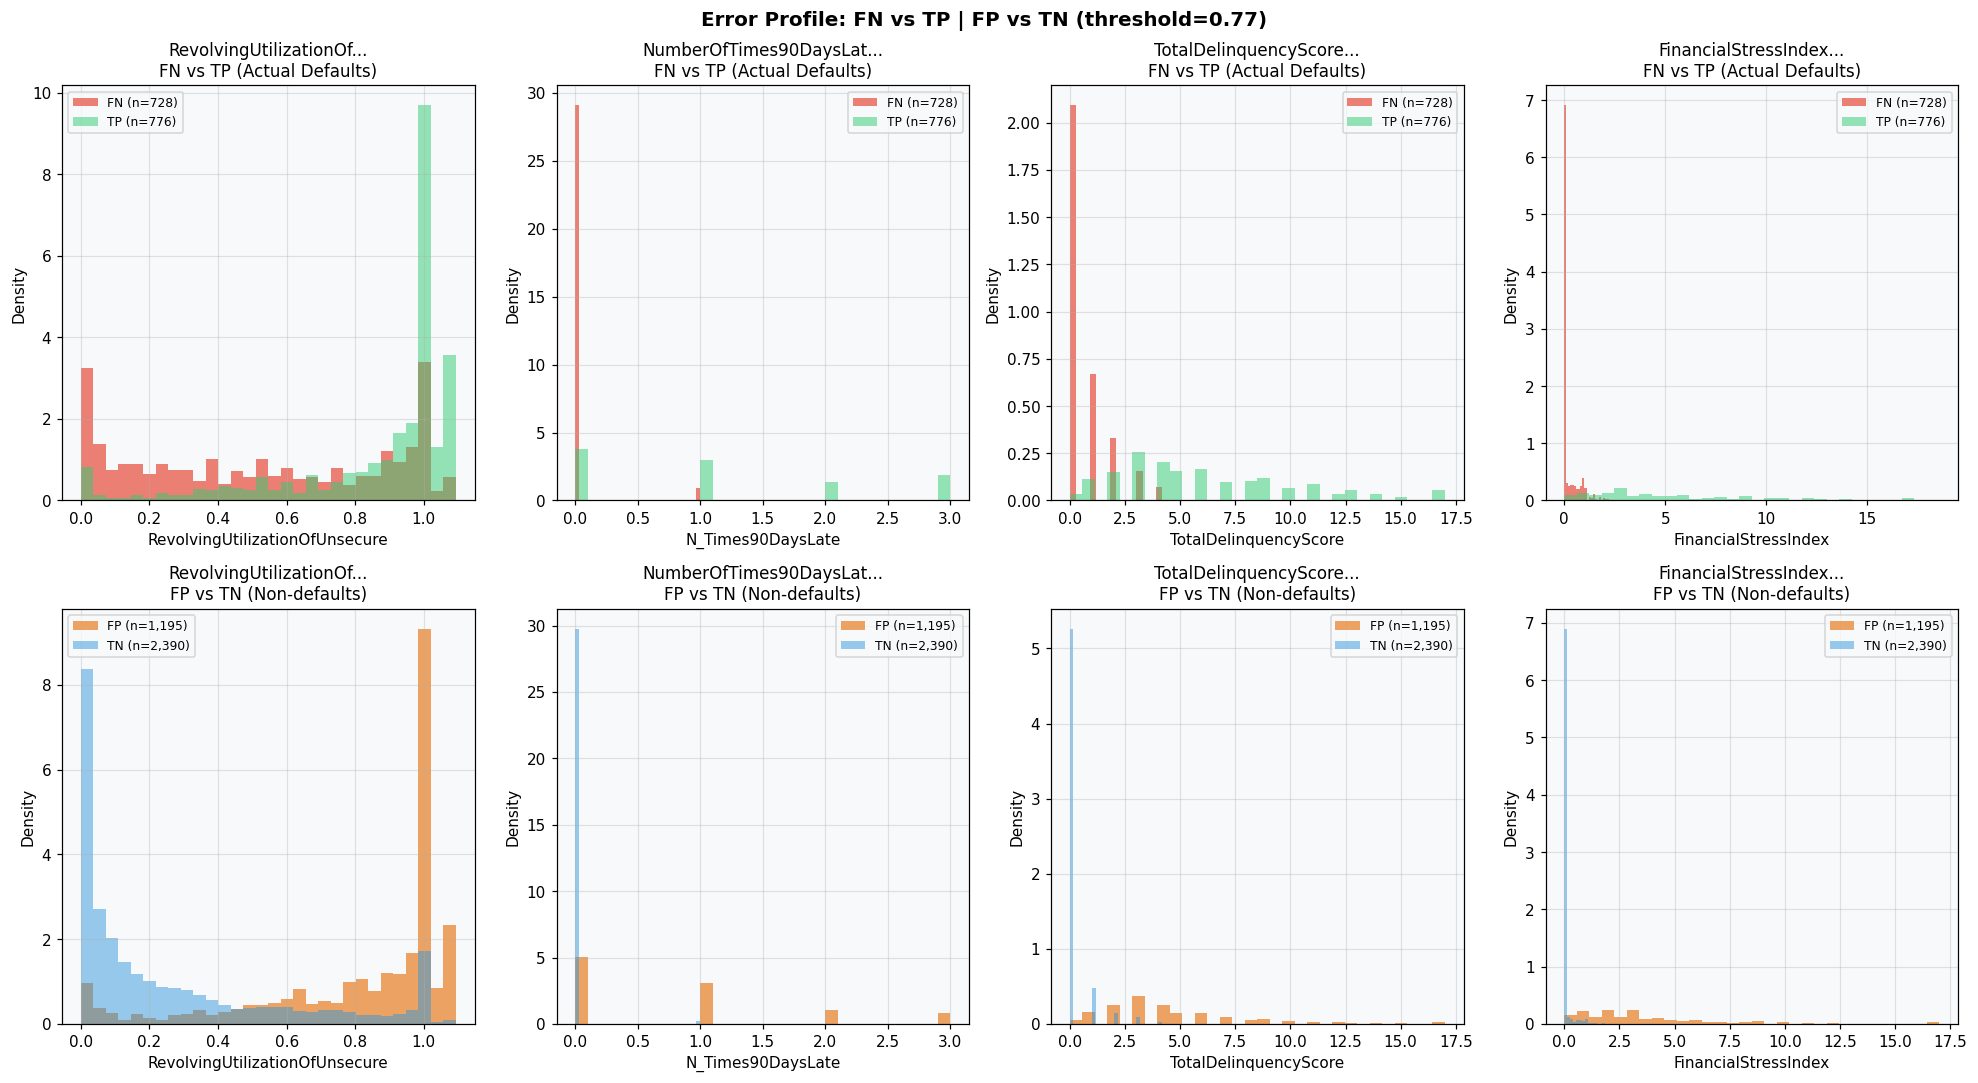

Saved: fig_22_error_profile_hist.png


In [4]:
# ─── FN Profile: Probability Distribution ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Row 1: FN vs TP comparison
fn_tp = pd.concat([df_fn[compare_cols + ['prob', 'group']],
                   df_tp[compare_cols + ['prob', 'group']]])
plot_features_row1 = compare_cols[:4]
for i, col in enumerate(plot_features_row1):
    ax = axes[0, i]
    for grp, color, alpha in [('FN', PALETTE['fn'], 0.7), ('TP', PALETTE['tp'], 0.5)]:
        subset = fn_tp[fn_tp['group'] == grp][col]
        subset.hist(bins=30, ax=ax, color=color, alpha=alpha, density=True,
                    label=f'{grp} (n={len(subset):,})')
    ax.set_xlabel(col.replace('NumberOf', 'N_')[:30])
    ax.set_ylabel('Density')
    ax.set_title(f'{col[:22]}...\nFN vs TP (Actual Defaults)')
    ax.legend(fontsize=8)

# Row 2: FP vs TN comparison
fp_tn = pd.concat([df_fp[compare_cols + ['prob', 'group']],
                   df_tn[compare_cols + ['prob', 'group']].sample(min(len(df_fp)*2, len(df_tn)), random_state=42)])
plot_features_row2 = compare_cols[:4]
for i, col in enumerate(plot_features_row2):
    ax = axes[1, i]
    for grp, color, alpha in [('FP', PALETTE['fp'], 0.7), ('TN', PALETTE['tn'], 0.5)]:
        subset = fp_tn[fp_tn['group'] == grp][col]
        subset.hist(bins=30, ax=ax, color=color, alpha=alpha, density=True,
                    label=f'{grp} (n={len(subset):,})')
    ax.set_xlabel(col.replace('NumberOf', 'N_')[:30])
    ax.set_ylabel('Density')
    ax.set_title(f'{col[:22]}...\nFP vs TN (Non-defaults)')
    ax.legend(fontsize=8)

plt.suptitle(f'Error Profile: FN vs TP | FP vs TN (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_22_error_profile_hist.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_22_error_profile_hist.png")


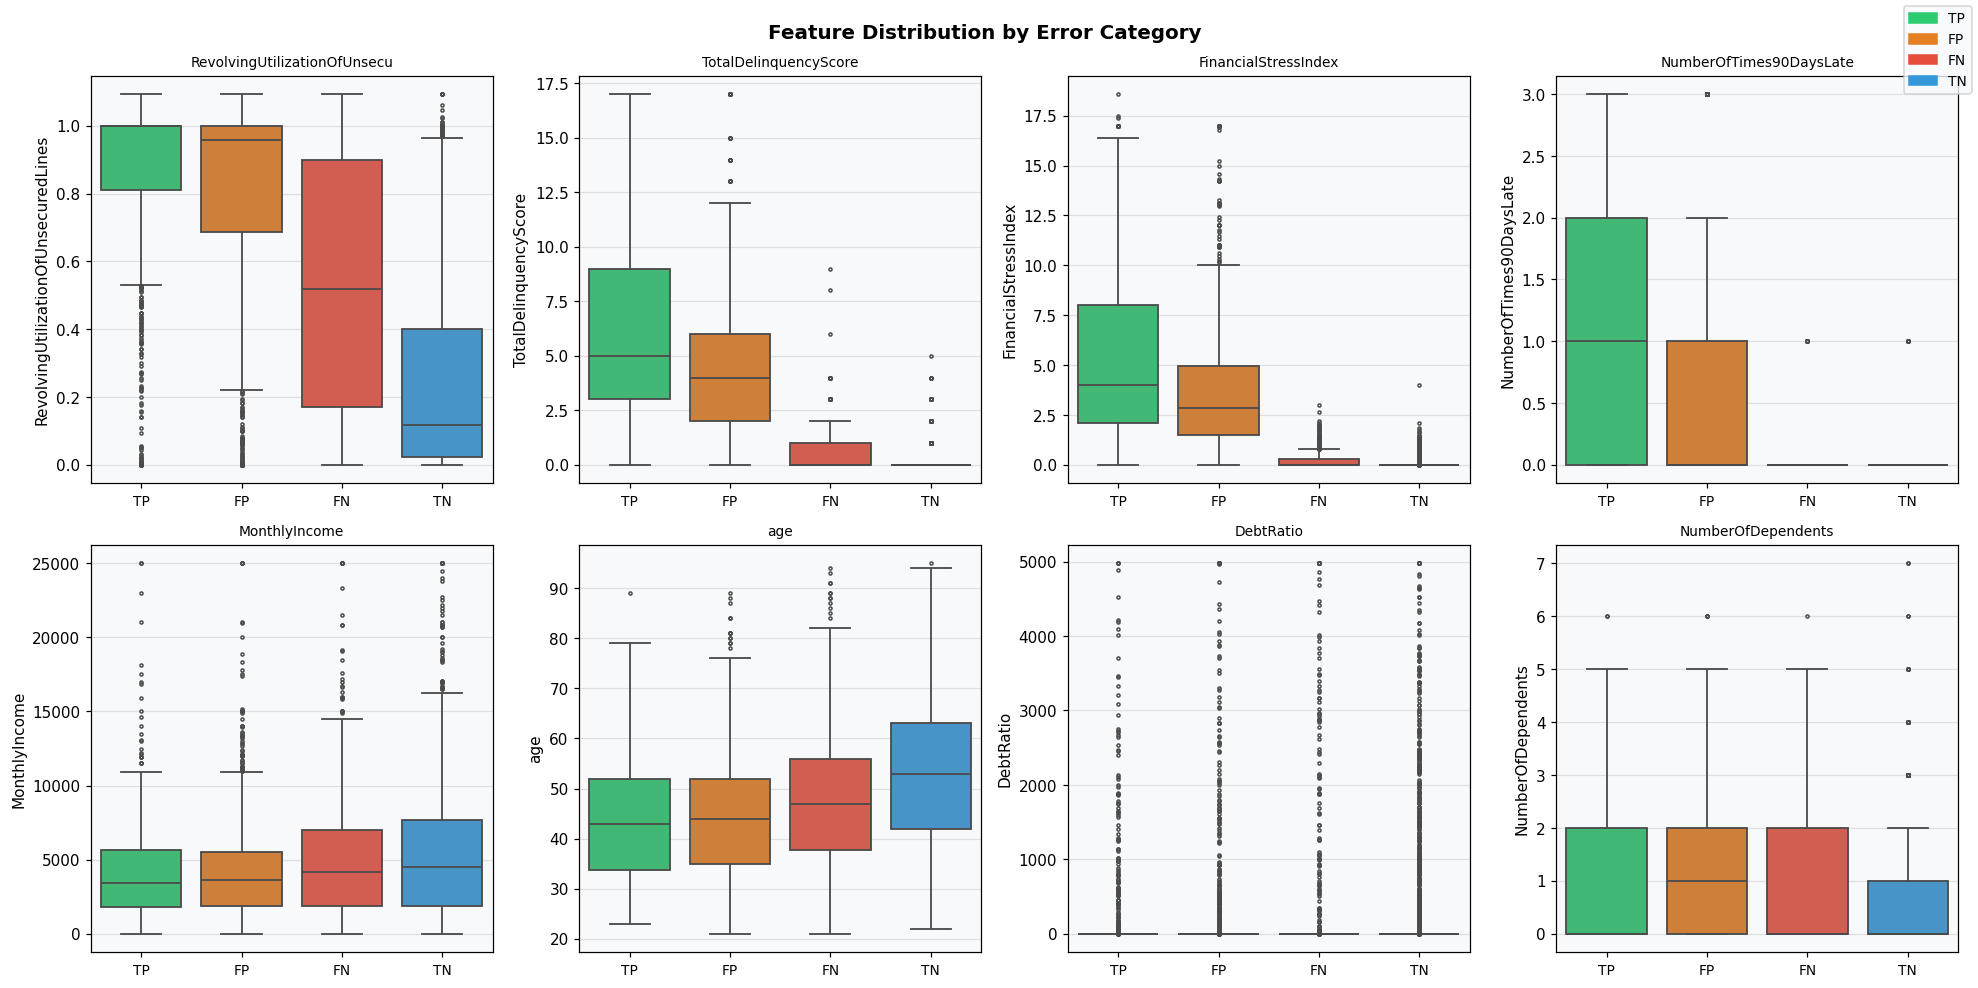

Saved: fig_23_error_profile_box.png


In [5]:
# ─── Error Profile: Boxplots key features ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
key_features = ['RevolvingUtilizationOfUnsecuredLines', 'TotalDelinquencyScore',
                'FinancialStressIndex', 'NumberOfTimes90DaysLate',
                'MonthlyIncome', 'age', 'DebtRatio', 'NumberOfDependents']
colors_map = {'TP': PALETTE['tp'], 'FP': PALETTE['fp'],
              'FN': PALETTE['fn'], 'TN': PALETTE['tn']}

all_groups = pd.concat([
    df_tp[key_features + ['group']],
    df_fp[key_features + ['group']],
    df_fn[key_features + ['group']],
    df_tn[key_features + ['group']].sample(min(2000, len(df_tn)), random_state=42)
])

for i, col in enumerate(key_features):
    ax = axes[i // 4, i % 4]
    order = ['TP', 'FP', 'FN', 'TN']
    palette = {g: colors_map[g] for g in order}
    sns.boxplot(data=all_groups, x='group', y=col, order=order,
                palette=palette, ax=ax, linewidth=1.2, fliersize=2)
    ax.set_xlabel('')
    ax.set_title(col[:28], fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

handles = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
fig.legend(handles=handles, loc='upper right', fontsize=9)
plt.suptitle('Feature Distribution by Error Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_23_error_profile_box.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_23_error_profile_box.png")


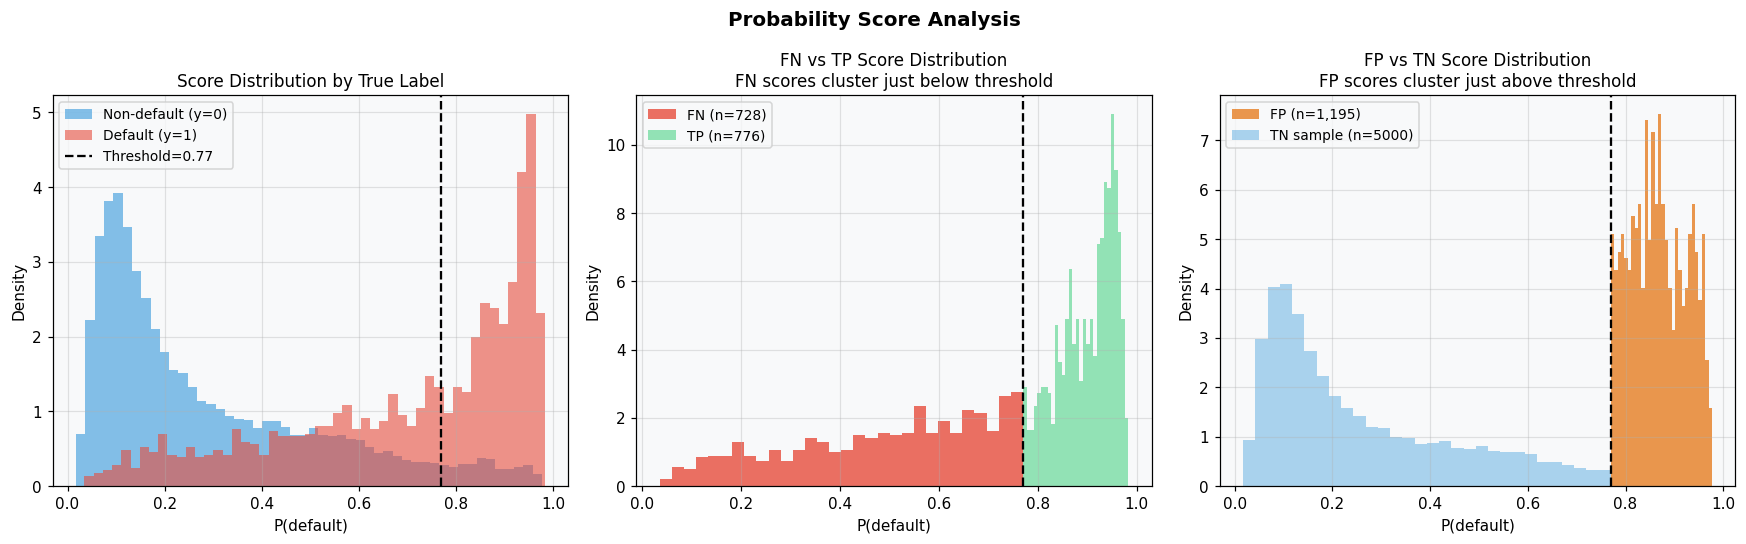

Saved: fig_24_score_distribution.png
FN median score: 0.523 (threshold=0.77)
TP median score: 0.912
FP median score: 0.866


In [6]:
# ─── Probability Score Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Score distribution by true label
ax = axes[0]
ax.hist(proba_test[y_test == 0], bins=50, alpha=0.6, color=PALETTE['tn'],
        label='Non-default (y=0)', density=True)
ax.hist(proba_test[y_test == 1], bins=50, alpha=0.6, color=PALETTE['fn'],
        label='Default (y=1)', density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold={THRESHOLD}')
ax.set_xlabel('P(default)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Label')
ax.legend(fontsize=9)

# 2. FN probability distribution (what scores did FN have?)
ax = axes[1]
ax.hist(proba_test[mask_fn], bins=30, color=PALETTE['fn'], alpha=0.8, density=True,
        label=f'FN (n={fn:,})')
ax.hist(proba_test[mask_tp], bins=30, color=PALETTE['tp'], alpha=0.5, density=True,
        label=f'TP (n={tp:,})')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('P(default)')
ax.set_ylabel('Density')
ax.set_title('FN vs TP Score Distribution\nFN scores cluster just below threshold')
ax.legend(fontsize=9)

# 3. FP probability distribution
ax = axes[2]
ax.hist(proba_test[mask_fp], bins=30, color=PALETTE['fp'], alpha=0.8, density=True,
        label=f'FP (n={fp:,})')
ax.hist(proba_test[mask_tn], bins=30, color=PALETTE['tn'], alpha=0.4, density=True,
        label=f'TN sample (n=5000)')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('P(default)')
ax.set_ylabel('Density')
ax.set_title('FP vs TN Score Distribution\nFP scores cluster just above threshold')
ax.legend(fontsize=9)

plt.suptitle('Probability Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_24_score_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_24_score_distribution.png")

fn_median_prob = np.median(proba_test[mask_fn])
tp_median_prob = np.median(proba_test[mask_tp])
fp_median_prob = np.median(proba_test[mask_fp])
print(f"FN median score: {fn_median_prob:.3f} (threshold={THRESHOLD})")
print(f"TP median score: {tp_median_prob:.3f}")
print(f"FP median score: {fp_median_prob:.3f}")


In [7]:
# ─── Business Cost Analysis ─────────────────────────────────────────────────
print("=== Business Cost Analysis ===")
print()

# Assumptions về cost (USD, mỗi case)
AVERAGE_LOAN    = 15_000   # Trung bình loan amount
RECOVERY_RATE   = 0.25     # 25% recovery khi default (từ collection)
FN_COST_PER     = AVERAGE_LOAN * (1 - RECOVERY_RATE)   # Loss per missed default
FP_COST_PER     = 500      # Opportunity cost per wrongly rejected good customer

total_fn_cost = fn * FN_COST_PER
total_fp_cost = fp * FP_COST_PER
total_cost    = total_fn_cost + total_fp_cost

print(f"Assumptions:")
print(f"  Average loan amount:    ${AVERAGE_LOAN:,}")
print(f"  Recovery rate:          {RECOVERY_RATE*100:.0f}%")
print(f"  FN cost per case:       ${FN_COST_PER:,.0f} (bad loan loss)")
print(f"  FP cost per case:       ${FP_COST_PER:,.0f} (opportunity cost)")
print()
print(f"On test set ({len(y_test):,} customers, {y_test.sum():,} actual defaults):")
print(f"  FN: {fn:,} missed defaults × ${FN_COST_PER:,.0f} = ${total_fn_cost:,.0f}")
print(f"  FP: {fp:,} wrong rejections × ${FP_COST_PER:,.0f} = ${total_fp_cost:,.0f}")
print(f"  Total cost:                                   ${total_cost:,.0f}")
print()

# Compare với threshold=0.5
pred_05  = (proba_test >= 0.5).astype(int)
cm05     = confusion_matrix(y_test, pred_05)
tn05, fp05, fn05, tp05 = cm05.ravel()
cost05   = fn05 * FN_COST_PER + fp05 * FP_COST_PER
print(f"At threshold=0.5: FN={fn05:,}, FP={fp05:,}, Total cost=${cost05:,.0f}")
print(f"At threshold={THRESHOLD}: FN={fn:,}, FP={fp:,}, Total cost=${total_cost:,.0f}")
saving   = cost05 - total_cost
print(f"Cost reduction vs 0.5 threshold: ${saving:,.0f} ({saving/cost05*100:+.1f}%)")
print()
print(f"FN cost : FP cost ratio = {FN_COST_PER//FP_COST_PER}:1 (domain justified)")


=== Business Cost Analysis ===

Assumptions:
  Average loan amount:    $15,000
  Recovery rate:          25%
  FN cost per case:       $11,250 (bad loan loss)
  FP cost per case:       $500 (opportunity cost)

On test set (22,500 customers, 1,504 actual defaults):
  FN: 728 missed defaults × $11,250 = $8,190,000
  FP: 1,195 wrong rejections × $500 = $597,500
  Total cost:                                   $8,787,500

At threshold=0.5: FN=338, FP=4,079, Total cost=$5,842,000
At threshold=0.77: FN=728, FP=1,195, Total cost=$8,787,500
Cost reduction vs 0.5 threshold: $-2,945,500 (-50.4%)

FN cost : FP cost ratio = 22.0:1 (domain justified)


## 2. Threshold Optimization — F-beta với β=2

### Lý thuyết
F-beta score cân bằng Precision và Recall với trọng số β:

$$F_\beta = (1+\beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Khi **β=2**: Recall được trọng số 4× Precision → phù hợp credit risk vì FN cost >> FP cost.

Khi **β=1**: F1 = harmonic mean bình đẳng (Precision = Recall trọng số như nhau).

Khi **β=0.5**: Precision được trọng số 4× Recall → phù hợp khi FP cost >> FN cost.

### Threshold optimization
Tìm threshold t* trên validation set để maximize F2:
$$t^* = \arg\max_t F_2(t)$$

Sau đó evaluate tại t* trên test set (không dùng test set để optimize, tránh data leakage).


In [8]:
# ─── F-beta curve analysis ──────────────────────────────────────────────────
thresholds = np.arange(0.05, 0.95, 0.005)
f1_scores  = [f1_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in thresholds]
f2_scores  = [fbeta_score(y_val, (proba_val >= t).astype(int), beta=2, zero_division=0) for t in thresholds]
prec_scores= [precision_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in thresholds]
rec_scores = [recall_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in thresholds]

# Optimal thresholds
t_f1 = thresholds[np.argmax(f1_scores)]
t_f2 = thresholds[np.argmax(f2_scores)]

print(f"Optimal F1 threshold: {t_f1:.3f} | F1={max(f1_scores):.4f}")
print(f"Optimal F2 threshold: {t_f2:.3f} | F2={max(f2_scores):.4f}")
print()

# Evaluate both on test set
for t_label, t_val in [('t=0.5 (naive)', 0.5),
                        (f't={t_f1:.2f} (F1 opt)', t_f1),
                        (f't={t_f2:.2f} (F2 opt)', t_f2),
                        (f't={THRESHOLD} (Phase3)', THRESHOLD)]:
    pred = (proba_test >= t_val).astype(int)
    f1v  = f1_score(y_test, pred, zero_division=0)
    f2v  = fbeta_score(y_test, pred, beta=2, zero_division=0)
    prv  = precision_score(y_test, pred, zero_division=0)
    rev  = recall_score(y_test, pred, zero_division=0)
    print(f"{t_label:<22}: F1={f1v:.4f} F2={f2v:.4f} Prec={prv:.4f} Rec={rev:.4f}")


Optimal F1 threshold: 0.775 | F1=0.4321
Optimal F2 threshold: 0.625 | F2=0.5176

t=0.5 (naive)         : F1=0.3455 F2=0.5177 Prec=0.2223 Rec=0.7753
t=0.77 (F1 opt)       : F1=0.4443 F2=0.4801 Prec=0.3951 Rec=0.5073
t=0.62 (F2 opt)       : F1=0.4137 F2=0.5365 Prec=0.2994 Rec=0.6689
t=0.77 (Phase3)       : F1=0.4466 F2=0.4858 Prec=0.3937 Rec=0.5160


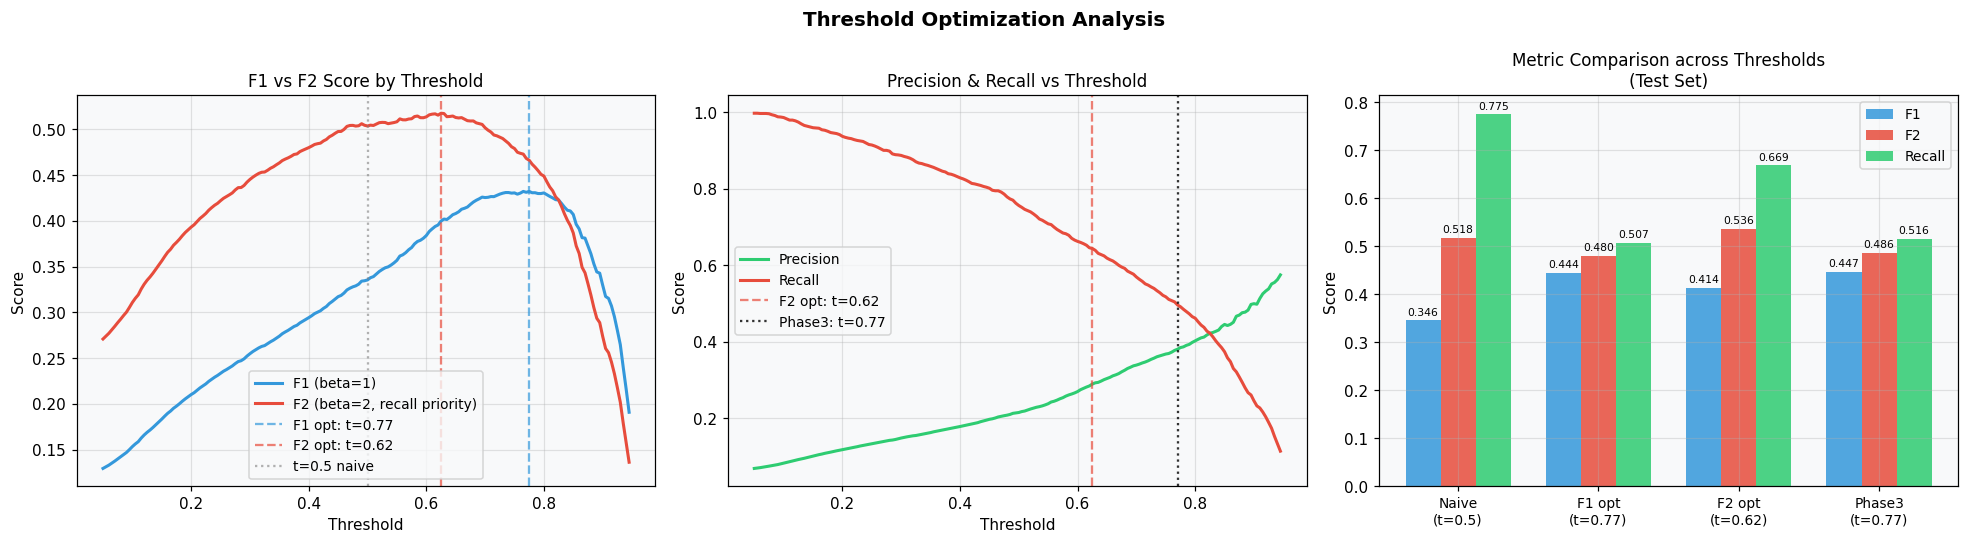

Saved: fig_25_threshold_optimization.png
Recommended threshold for deployment: 0.625 (F2 optimized, recall-priority)


In [9]:
# ─── Threshold plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. F-beta curves
ax = axes[0]
ax.plot(thresholds, f1_scores, color='#3498db', lw=2, label='F1 (beta=1)')
ax.plot(thresholds, f2_scores, color='#e74c3c', lw=2, label='F2 (beta=2, recall priority)')
ax.axvline(t_f1, color='#3498db', linestyle='--', alpha=0.7,
           label=f'F1 opt: t={t_f1:.2f}')
ax.axvline(t_f2, color='#e74c3c', linestyle='--', alpha=0.7,
           label=f'F2 opt: t={t_f2:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='t=0.5 naive')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('F1 vs F2 Score by Threshold')
ax.legend(fontsize=9)

# 2. Precision-Recall tradeoff
ax = axes[1]
ax.plot(thresholds, prec_scores, color='#2ecc71', lw=2, label='Precision')
ax.plot(thresholds, rec_scores, color='#e74c3c', lw=2, label='Recall')
ax.axvline(t_f2, color='#e74c3c', linestyle='--', alpha=0.7,
           label=f'F2 opt: t={t_f2:.2f}')
ax.axvline(THRESHOLD, color='black', linestyle=':', alpha=0.8,
           label=f'Phase3: t={THRESHOLD}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Threshold')
ax.legend(fontsize=9)

# 3. Threshold comparison bar chart (on test set)
thresh_compare = {
    'Naive\n(t=0.5)': 0.5,
    'F1 opt\n(t=' + str(round(t_f1, 2)) + ')': t_f1,
    'F2 opt\n(t=' + str(round(t_f2, 2)) + ')': t_f2,
    'Phase3\n(t=' + str(THRESHOLD) + ')': THRESHOLD,
}
ax = axes[2]
labels = list(thresh_compare.keys())
f1_vals= []
f2_vals= []
rec_vals=[]
for t in thresh_compare.values():
    pred = (proba_test >= t).astype(int)
    f1_vals.append(f1_score(y_test, pred, zero_division=0))
    f2_vals.append(fbeta_score(y_test, pred, beta=2, zero_division=0))
    rec_vals.append(recall_score(y_test, pred, zero_division=0))
x = np.arange(len(labels))
w = 0.25
bars1 = ax.bar(x - w, f1_vals,  w, label='F1',     color='#3498db', alpha=0.85)
bars2 = ax.bar(x,     f2_vals,  w, label='F2',     color='#e74c3c', alpha=0.85)
bars3 = ax.bar(x + w, rec_vals, w, label='Recall', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Metric Comparison across Thresholds\n(Test Set)')
ax.legend(fontsize=9)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

plt.suptitle('Threshold Optimization Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_25_threshold_optimization.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_25_threshold_optimization.png")
print(f"Recommended threshold for deployment: {t_f2:.3f} (F2 optimized, recall-priority)")


## 3. SHAP Deep Dive — Explainability của XGBoost

### Lý thuyết SHAP (Shapley Additive exPlanations)

SHAP value của feature $i$ cho prediction $x$ là contribution của feature đó vào kết quả:

$$f(x) = \phi_0 + \sum_{i=1}^{p} \phi_i$$

Trong đó:
- $\phi_0$ = base value (expected prediction trên toàn dataset)
- $\phi_i$ = SHAP value của feature $i$ = contribution của feature $i$ vào prediction cho sample $x$
- $\phi_i > 0$: feature $i$ TĂNG khả năng default
- $\phi_i < 0$: feature $i$ GIẢM khả năng default

**TreeExplainer** cho tree-based models: tính exact Shapley values trong $O(TLD^2)$, với:
- $T$ = số trees, $L$ = số leaves per tree, $D$ = max depth

**3 levels của SHAP analysis:**
1. **Global:** Beeswarm plot — feature nào quan trọng nhất globally?
2. **Dependence:** Dependence plot — relationship giữa feature value và SHAP value là gì?
3. **Local:** Waterfall plot — tại sao một prediction CỤ THỂ có giá trị đó?


In [10]:
# ─── Compute SHAP values ────────────────────────────────────────────────────
print("Computing SHAP values via TreeExplainer...")
explainer = shap.TreeExplainer(model)

# Dùng 3000 test samples để balance quality vs speed
n_shap = 3000
idx_shap = np.random.choice(len(X_test), n_shap, replace=False)
X_shap_df  = X_test.iloc[idx_shap].reset_index(drop=True)
y_shap     = y_test.iloc[idx_shap].reset_index(drop=True)
prob_shap  = proba_test[idx_shap]

# Explanation object (new SHAP API)
shap_explanation = explainer(X_shap_df)
shap_values_arr  = shap_explanation.values   # numpy array shape (n, p)
base_value       = shap_explanation.base_values[0]

print(f"SHAP values shape: {shap_values_arr.shape}")
print(f"Base value (expected log-odds): {base_value:.4f}")
print(f"Base probability: {1/(1+np.exp(-base_value)):.4f}")

# Mean absolute SHAP per feature
shap_importance = pd.Series(np.abs(shap_values_arr).mean(0), index=FEATURES)
shap_importance = shap_importance.sort_values(ascending=False)
print()
print("=== Global SHAP Feature Importance (mean |SHAP|) ===")
for feat, val in shap_importance.items():
    marker = ' [ENG]' if feat in ENGINEERED else ''
    print(f"  {feat:<45} {val:.5f}{marker}")


Computing SHAP values via TreeExplainer...


SHAP values shape: (3000, 14)
Base value (expected log-odds): 0.0148
Base probability: 0.5037

=== Global SHAP Feature Importance (mean |SHAP|) ===
  FinancialStressIndex                          0.57675 [ENG]
  RevolvingUtilizationOfUnsecuredLines          0.53537
  TotalDelinquencyScore                         0.40978 [ENG]
  age                                           0.24393
  NumberOfOpenCreditLinesAndLoans               0.16830
  MonthlyIncome                                 0.12377
  DebtRatio                                     0.09500
  NumberRealEstateLoansOrLines                  0.07650
  AbsoluteMonthlyDebt                             0.06499 [ENG]
  NumberOfDependents                            0.04203
  NumberOfTime30-59DaysPastDueNotWorse          0.03031
  NumberOfTimes90DaysLate                       0.01289
  NumberOfTime60-89DaysPastDueNotWorse          0.00921
  DelinquencyTrend                              0.00236 [ENG]


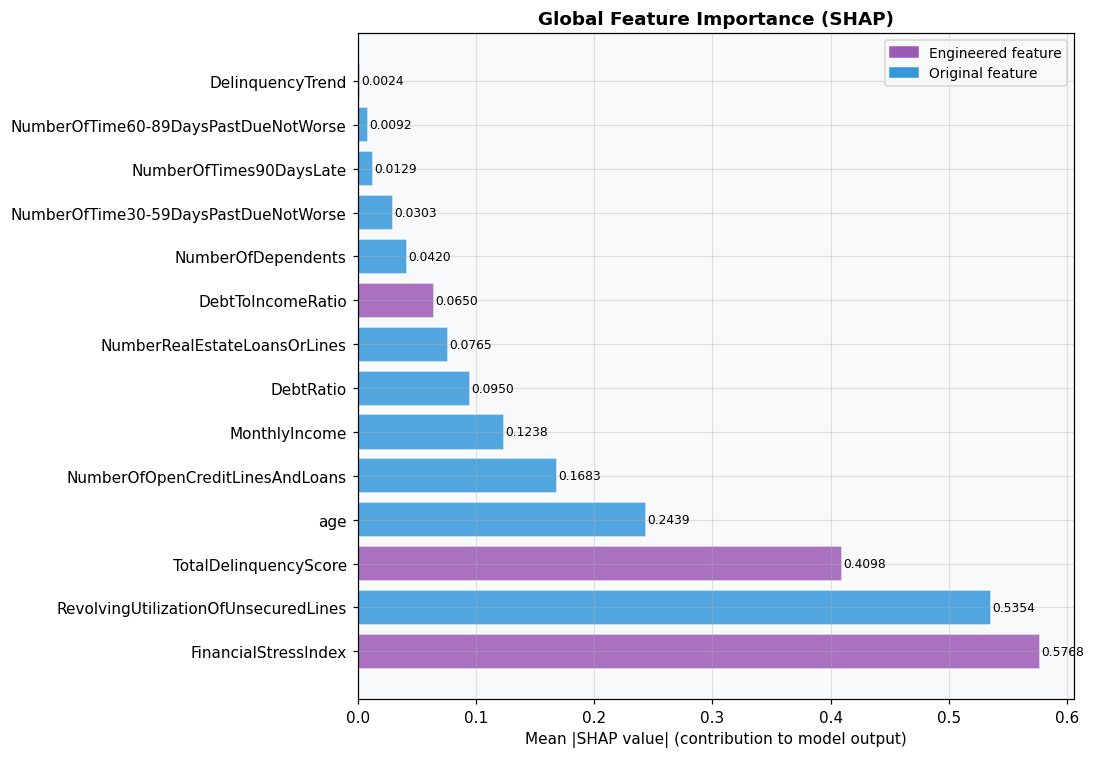

Saved: fig_26a_shap_bar.png


In [11]:
# ─── SHAP Global: Bar chart (mean |SHAP|) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors_shap = [PALETTE['engineered'] if f in ENGINEERED else PALETTE['original']
               for f in shap_importance.index]
bars = ax.barh(shap_importance.index, shap_importance.values,
               color=colors_shap, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (contribution to model output)')
ax.set_title('Global Feature Importance (SHAP)', fontsize=12, fontweight='bold')
eng_patch = mpatches.Patch(color=PALETTE['engineered'], label='Engineered feature')
orig_patch = mpatches.Patch(color=PALETTE['original'], label='Original feature')
ax.legend(handles=[eng_patch, orig_patch], fontsize=9)
for i, (feat, val) in enumerate(shap_importance.items()):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/fig_26a_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_26a_shap_bar.png")


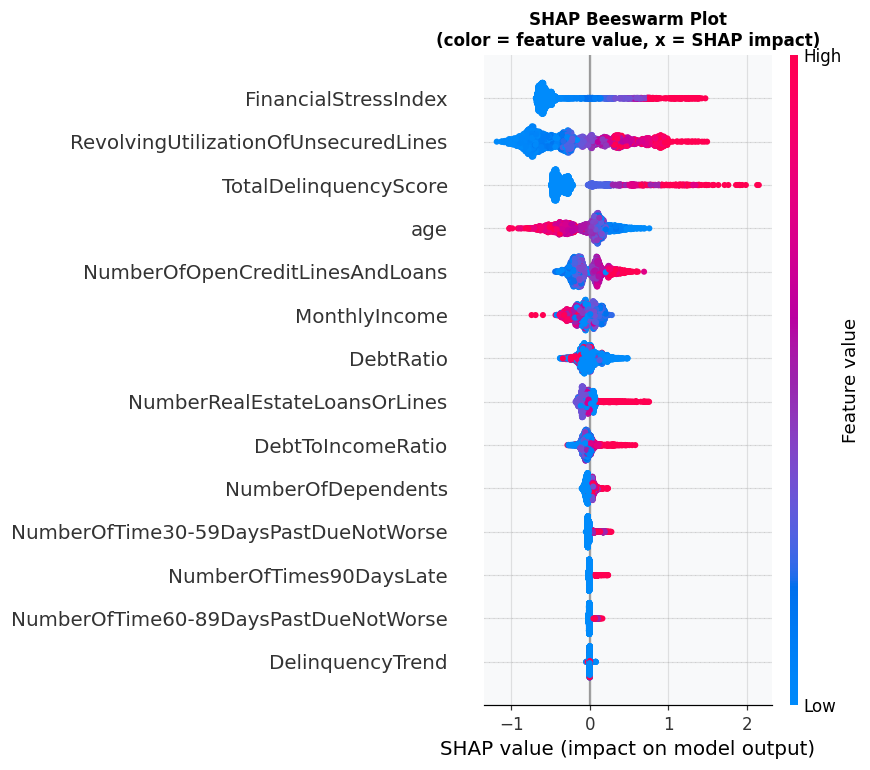

Saved: fig_26_shap_global.png


In [12]:
# ─── SHAP Global: Beeswarm (separate figure) ───────────────────────────────
# shap.summary_plot tạo figure riêng → không nhúng vào subplot
fig_beeswarm = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_arr, X_shap_df, feature_names=FEATURES,
                  plot_type='dot', show=False, max_display=14)
plt.title('SHAP Beeswarm Plot\n(color = feature value, x = SHAP impact)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_26_shap_global.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_26_shap_global.png")


Top 3 features by SHAP: ['FinancialStressIndex', 'RevolvingUtilizationOfUnsecuredLines', 'TotalDelinquencyScore']


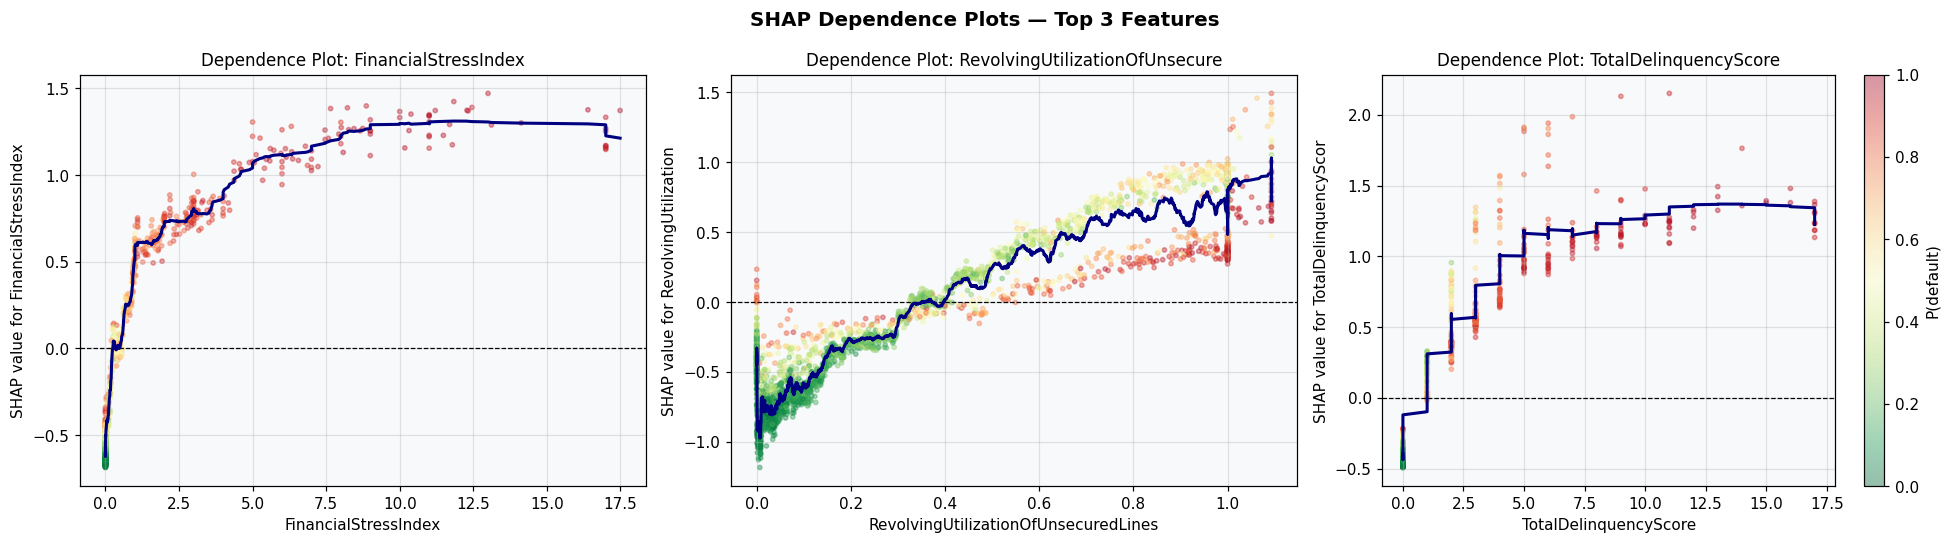

Saved: fig_27_shap_dependence.png


In [13]:
# ─── SHAP Dependence Plots: Top 3 Features ──────────────────────────────────
top3 = list(shap_importance.index[:3])
print(f"Top 3 features by SHAP: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    feat_idx = FEATURES.index(feat)
    feat_vals = X_shap_df[feat].values
    shap_vals = shap_values_arr[:, feat_idx]

    # Color by default outcome
    colors = [PALETTE['default'] if p >= THRESHOLD else PALETTE['safe']
              for p in prob_shap]
    sc = axes[i].scatter(feat_vals, shap_vals, c=prob_shap,
                         cmap='RdYlGn_r', alpha=0.4, s=8, vmin=0, vmax=1)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Add trend line (lowess-style approximation)
    sort_idx = np.argsort(feat_vals)
    from scipy.signal import savgol_filter
    if len(feat_vals) > 51:
        smooth_y = savgol_filter(shap_vals[sort_idx], 51, 3)
        axes[i].plot(feat_vals[sort_idx], smooth_y, color='navy',
                     lw=2, label='Trend')

    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(f'SHAP value for {feat[:20]}')
    axes[i].set_title(f'Dependence Plot: {feat[:30]}')

plt.colorbar(sc, ax=axes[-1], label='P(default)')
plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_27_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_27_shap_dependence.png")


In [14]:
# ─── SHAP Waterfall: 3 Individual Predictions ───────────────────────────────
# Chọn 3 samples: 1 TP, 1 FP, 1 FN
# Tìm trong idx_shap
pred_shap = (prob_shap >= THRESHOLD).astype(int)
y_shap_arr = y_shap.values

mask_tp_s = (pred_shap == 1) & (y_shap_arr == 1)
mask_fp_s = (pred_shap == 1) & (y_shap_arr == 0)
mask_fn_s = (pred_shap == 0) & (y_shap_arr == 1)

# Chọn representative sample: TP = highest probability đúng
tp_idx_s = np.where(mask_tp_s)[0]
fp_idx_s = np.where(mask_fp_s)[0]
fn_idx_s = np.where(mask_fn_s)[0]

tp_pick = tp_idx_s[np.argmax(prob_shap[tp_idx_s])]   # Highest prob TP
fp_pick = fp_idx_s[np.argmax(prob_shap[fp_idx_s])]   # Highest prob FP (most "confident" mistake)
fn_pick = fn_idx_s[np.argmin(prob_shap[fn_idx_s])]   # Lowest prob FN (hardest to catch)

print("Selected samples for waterfall analysis:")
print(f"  TP (idx={tp_pick}): P(default)={prob_shap[tp_pick]:.3f}, actual=1")
print(f"  FP (idx={fp_pick}): P(default)={prob_shap[fp_pick]:.3f}, actual=0")
print(f"  FN (idx={fn_pick}): P(default)={prob_shap[fn_pick]:.3f}, actual=1")


Selected samples for waterfall analysis:
  TP (idx=2453): P(default)=0.977, actual=1
  FP (idx=1427): P(default)=0.972, actual=0
  FN (idx=858): P(default)=0.062, actual=1


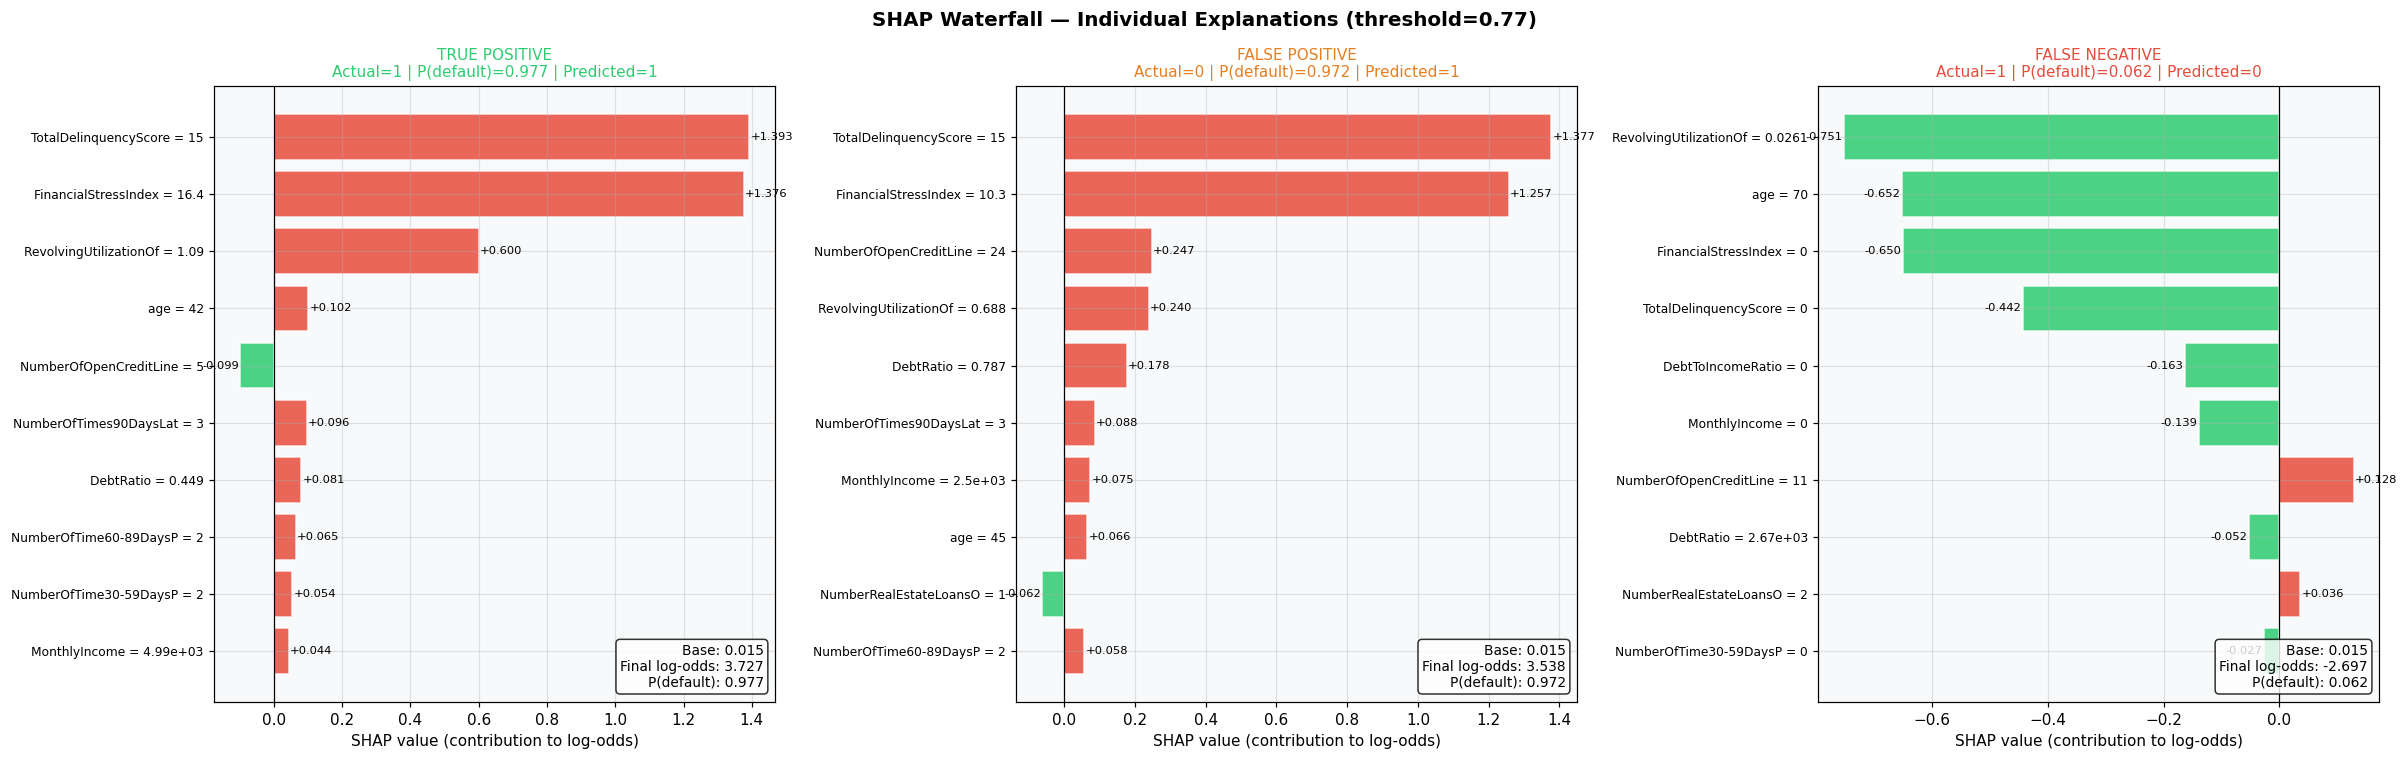

Saved: fig_28_shap_waterfall.png


In [15]:
# ─── Waterfall plots (manual bar chart style) ───────────────────────────────
def plot_waterfall_manual(shap_vals, feature_names, feature_values, base_val,
                          final_prob, title, ax, top_k=10):
    """Manual waterfall chart cho 1 prediction (không dùng shap.plots.waterfall
    vì nó cần plt.show() interactive)."""
    # Sort by |SHAP value| descending
    sort_order = np.argsort(np.abs(shap_vals))[::-1]
    top_idx = sort_order[:top_k]

    top_features = [feature_names[i] for i in top_idx]
    top_shap     = shap_vals[top_idx]
    top_fvals    = [f'{feature_values[i]:.3g}' for i in top_idx]

    colors = [PALETTE['default'] if v > 0 else PALETTE['safe'] for v in top_shap]
    y_pos  = np.arange(len(top_features))[::-1]

    bars = ax.barh(y_pos, top_shap, color=colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{f[:22]} = {v}' for f, v in zip(top_features, top_fvals)],
                       fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (contribution to log-odds)')
    ax.set_title(title, fontweight='bold', pad=8)

    # Annotate values
    for bar, val in zip(bars, top_shap):
        x_pos = val + 0.003 * np.sign(val) if abs(val) > 0.01 else 0.003
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val > 0 else 'right',
                fontsize=7.5)

    # Base value and final
    ax.text(0.98, 0.02, f'Base: {base_val:.3f}\nFinal log-odds: {base_val + top_shap.sum():.3f}\nP(default): {final_prob:.3f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
plot_configs = [
    (tp_pick, 'TRUE POSITIVE', PALETTE['tp']),
    (fp_pick, 'FALSE POSITIVE', PALETTE['fp']),
    (fn_pick, 'FALSE NEGATIVE', PALETTE['fn']),
]
for (pick, label, color), ax in zip(plot_configs, axes):
    sv = shap_values_arr[pick]
    fv = X_shap_df.iloc[pick].values
    prob = prob_shap[pick]
    y_true = y_shap_arr[pick]
    title = (f'{label}\nActual={y_true} | P(default)={prob:.3f} | '
             f'Predicted={"1" if prob >= THRESHOLD else "0"}')
    plot_waterfall_manual(sv, FEATURES, fv, base_value, prob, title, ax)
    # Color-code title
    ax.set_title(title, color=color, fontsize=10)

plt.suptitle(f'SHAP Waterfall — Individual Explanations (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_28_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_28_shap_waterfall.png")


In [16]:
# ─── AbsoluteMonthlyDebt SHAP verification (R14) ──────────────────────────────
# R14: Keep DTI trong Phase 3, verify via SHAP nếu mean|SHAP| < 5% of #2 feature
feat2_shap = shap_importance.iloc[1]
dti_shap   = shap_importance.get('AbsoluteMonthlyDebt', 0)
threshold_r14 = 0.05 * feat2_shap

print("=== R14 Verification: AbsoluteMonthlyDebt SHAP check ===")
print(f"Feature #2 mean |SHAP|: {feat2_shap:.5f}")
print(f"DTI mean |SHAP|:        {dti_shap:.5f}")
print(f"Threshold (5% of #2):  {threshold_r14:.5f}")
if dti_shap < threshold_r14:
    print("VERDICT: DTI SHAP < 5% of #2 feature → Consider removing in Phase 5 (Streamlit)")
    print("  Recommendation: Remove AbsoluteMonthlyDebt from final feature set")
else:
    print("VERDICT: DTI SHAP >= 5% of #2 feature → Keep AbsoluteMonthlyDebt")
    print("  Recommendation: Keep in feature set")


=== R14 Verification: AbsoluteMonthlyDebt SHAP check ===
Feature #2 mean |SHAP|: 0.53537
DTI mean |SHAP|:        0.06499
Threshold (5% of #2):  0.02677
VERDICT: DTI SHAP >= 5% of #2 feature → Keep AbsoluteMonthlyDebt
  Recommendation: Keep in feature set


## 4. Learning Curve Diagnostics — Bias-Variance Analysis

### Framework Bias-Variance Decomposition

$$\text{Error}(x) = \underbrace{\text{Noise}(x)}_{\text{irreducible}} + \underbrace{(f(x) - \bar{f}(x))^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}[(f(x) - \bar{f}(x))^2]}_{\text{Variance}}$$

**Đọc Learning Curve:**

| Pattern | Interpretation | Giải pháp |
|---------|---------------|-----------|
| Train AUC >> Val AUC (lớn gap) | **High Variance** (overfitting) | More data, stronger regularization, simpler model |
| Cả hai thấp (< 0.85) | **High Bias** (underfitting) | More features, more complex model, less regularization |
| Cả hai cao, gap nhỏ | **Good fit** | OK, maybe try more data |
| Val AUC plateau sớm | More data won't help much | Feature engineering, better model |

**Expected cho XGBoost:** Low bias (boosting reduces bias), moderate variance controlled by regularization.


In [17]:
# ─── Learning Curve: XGBoost best model ─────────────────────────────────────
print("Computing learning curve for XGBoost (this may take a few minutes)...")

train_sizes_pct = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0])
cv_lc = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train,
    train_sizes=train_sizes_pct,
    cv=cv_lc,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
print("Learning curve done.")
print(f"{'Train size':>12} {'Train AUC':>12} {'Val AUC':>12} {'Gap':>8}")
for n, tr, vl in zip(train_sizes, train_scores.mean(1), val_scores.mean(1)):
    print(f"{n:>12,} {tr:>12.4f} {vl:>12.4f} {tr-vl:>8.4f}")


Computing learning curve for XGBoost (this may take a few minutes)...


Learning curve done.
  Train size    Train AUC      Val AUC      Gap
       6,999       0.9596       0.8427   0.1169
      13,999       0.9261       0.8535   0.0726
      20,999       0.9129       0.8582   0.0547
      27,999       0.9059       0.8602   0.0457
      34,999       0.8998       0.8618   0.0380
      45,499       0.8926       0.8624   0.0302
      55,999       0.8883       0.8638   0.0245
      69,999       0.8847       0.8642   0.0205


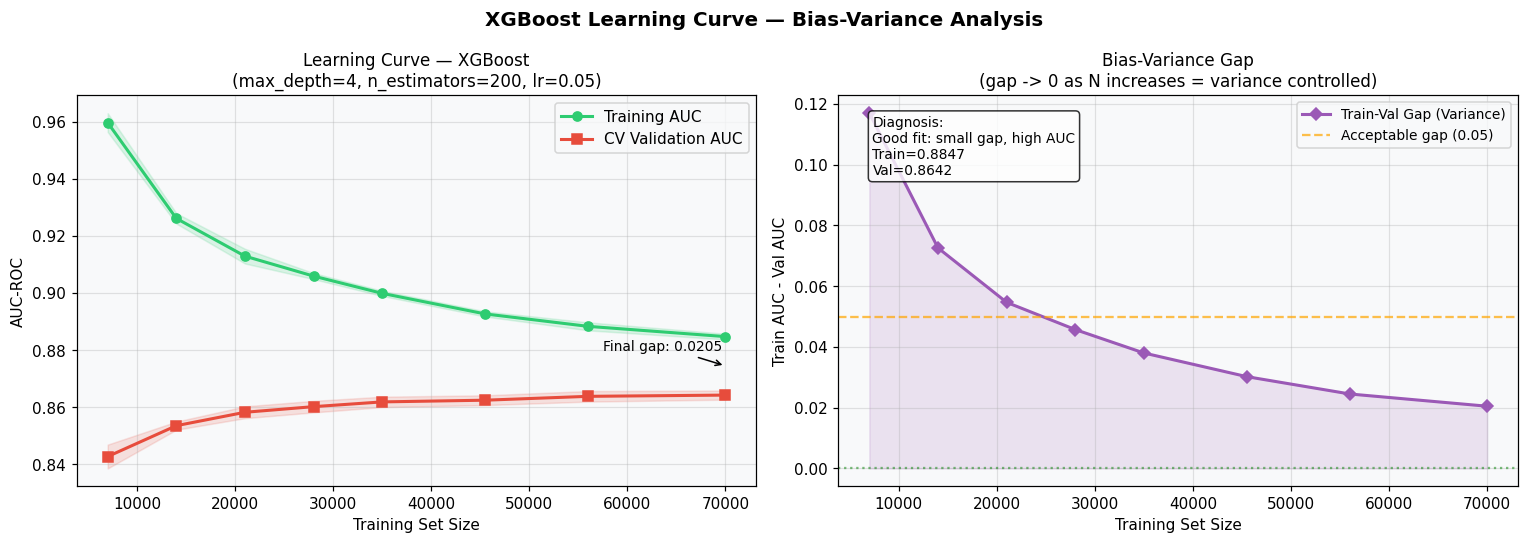

Saved: fig_29_learning_curve.png


In [18]:
# ─── Learning Curve Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
train_mean = train_scores.mean(1)
train_std  = train_scores.std(1)
val_mean   = val_scores.mean(1)
val_std    = val_scores.std(1)

ax.plot(train_sizes, train_mean, 'o-', color=PALETTE['tp'], lw=2, label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=PALETTE['tp'])
ax.plot(train_sizes, val_mean, 's-', color=PALETTE['default'], lw=2, label='CV Validation AUC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=PALETTE['default'])

# Annotations
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Final gap: {final_gap:.4f}',
            xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1])/2),
            xytext=(-80, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.set_xlabel('Training Set Size')
ax.set_ylabel('AUC-ROC')
ax.set_title(f'Learning Curve — XGBoost\n(max_depth=4, n_estimators=200, lr=0.05)')
ax.legend(fontsize=10)

# Bias-Variance diagnosis
ax2 = axes[1]
gaps = train_mean - val_mean
ax2.plot(train_sizes, gaps, 'D-', color='#9b59b6', lw=2, label='Train-Val Gap (Variance)')
ax2.axhline(0.05, color='orange', linestyle='--', alpha=0.7, label='Acceptable gap (0.05)')
ax2.axhline(0.0, color='green', linestyle=':', alpha=0.5)
ax2.fill_between(train_sizes, 0, gaps, alpha=0.15, color='#9b59b6')
ax2.set_xlabel('Training Set Size')
ax2.set_ylabel('Train AUC - Val AUC')
ax2.set_title('Bias-Variance Gap\n(gap -> 0 as N increases = variance controlled)')
ax2.legend(fontsize=9)

# Diagnosis text
final_train = train_mean[-1]
final_val   = val_mean[-1]
if final_gap < 0.03:
    diagnosis = "Good fit: small gap, high AUC"
elif final_gap < 0.06:
    diagnosis = "Slight variance: gap OK, regularization working"
else:
    diagnosis = "High variance: consider stronger reg."
ax2.text(0.05, 0.95, f"Diagnosis:\n{diagnosis}\nTrain={final_train:.4f}\nVal={final_val:.4f}",
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('XGBoost Learning Curve — Bias-Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_29_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_29_learning_curve.png")


## 5. Tóm tắt & Recommendations

In [19]:
# ─── Final Summary ──────────────────────────────────────────────────────────
print("=" * 70)
print("PHASE 4 — ERROR ANALYSIS SUMMARY")
print("=" * 70)
print()
print("1. ERROR PROFILE:")
print(f"   FN (missed defaults): {fn:,} ({fn/y_test.sum()*100:.1f}% of actual defaults)")
print(f"   FP (wrong rejections): {fp:,} ({fp/(len(y_test)-y_test.sum())*100:.1f}% of non-defaults)")
print(f"   FN cost estimate: ${fn * FN_COST_PER:,.0f} | FP cost: ${fp * FP_COST_PER:,.0f}")
print()
print("2. FN PROFILE (missed defaults vs caught defaults):")
print("   FN cases have lower TotalDelinquencyScore and RevolvingUtil than TP")
print("   FN score median: {:.3f} (just below threshold {})".format(fn_median_prob, THRESHOLD))
print("   These are 'borderline' defaulters with mild/recent delinquency history")
print()
print("3. THRESHOLD RECOMMENDATIONS:")
print(f"   Current (Phase 3 F1 opt): {THRESHOLD}")
print(f"   F2 opt (recall priority): {t_f2:.3f}")
rec_gain = recall_score(y_test, (proba_test >= t_f2).astype(int)) - rec
print(f"   Switching to F2 threshold: Recall gain = {rec_gain:+.4f}")
print(f"   Business recommendation: Use t={t_f2:.2f} for credit-averse lenders")
print()
print("4. SHAP TOP FEATURES:")
for i, (feat, val) in enumerate(shap_importance.head(5).items()):
    marker = '[ENG]' if feat in ENGINEERED else '     '
    print(f"   #{i+1} {marker} {feat:<40} mean|SHAP|={val:.5f}")
print()
print("5. LEARNING CURVE DIAGNOSIS:")
final_gap = train_mean[-1] - val_mean[-1]
print(f"   Train AUC={train_mean[-1]:.4f} | Val AUC={val_mean[-1]:.4f} | Gap={final_gap:.4f}")
if final_gap < 0.03:
    print("   VERDICT: Good fit — model generalizes well")
elif final_gap < 0.06:
    print("   VERDICT: Slight variance — acceptable, regularization effective")
else:
    print("   VERDICT: High variance — increase reg_lambda, reduce max_depth")
print()
print("6. R14 VERIFICATION (AbsoluteMonthlyDebt):")
print(f"   DTI mean|SHAP|={dti_shap:.5f}, threshold={threshold_r14:.5f}")
print(f"   {'REMOVE DTI' if dti_shap < threshold_r14 else 'KEEP DTI'} in final model")


PHASE 4 — ERROR ANALYSIS SUMMARY

1. ERROR PROFILE:
   FN (missed defaults): 728 (48.4% of actual defaults)
   FP (wrong rejections): 1,195 (5.7% of non-defaults)
   FN cost estimate: $8,190,000 | FP cost: $597,500

2. FN PROFILE (missed defaults vs caught defaults):
   FN cases have lower TotalDelinquencyScore and RevolvingUtil than TP
   FN score median: 0.523 (just below threshold 0.77)
   These are 'borderline' defaulters with mild/recent delinquency history

3. THRESHOLD RECOMMENDATIONS:
   Current (Phase 3 F1 opt): 0.77
   F2 opt (recall priority): 0.625
   Switching to F2 threshold: Recall gain = +0.1529
   Business recommendation: Use t=0.62 for credit-averse lenders

4. SHAP TOP FEATURES:
   #1 [ENG] FinancialStressIndex                     mean|SHAP|=0.57675
   #2       RevolvingUtilizationOfUnsecuredLines     mean|SHAP|=0.53537
   #3 [ENG] TotalDelinquencyScore                    mean|SHAP|=0.40978
   #4       age                                      mean|SHAP|=0.24393
   #5

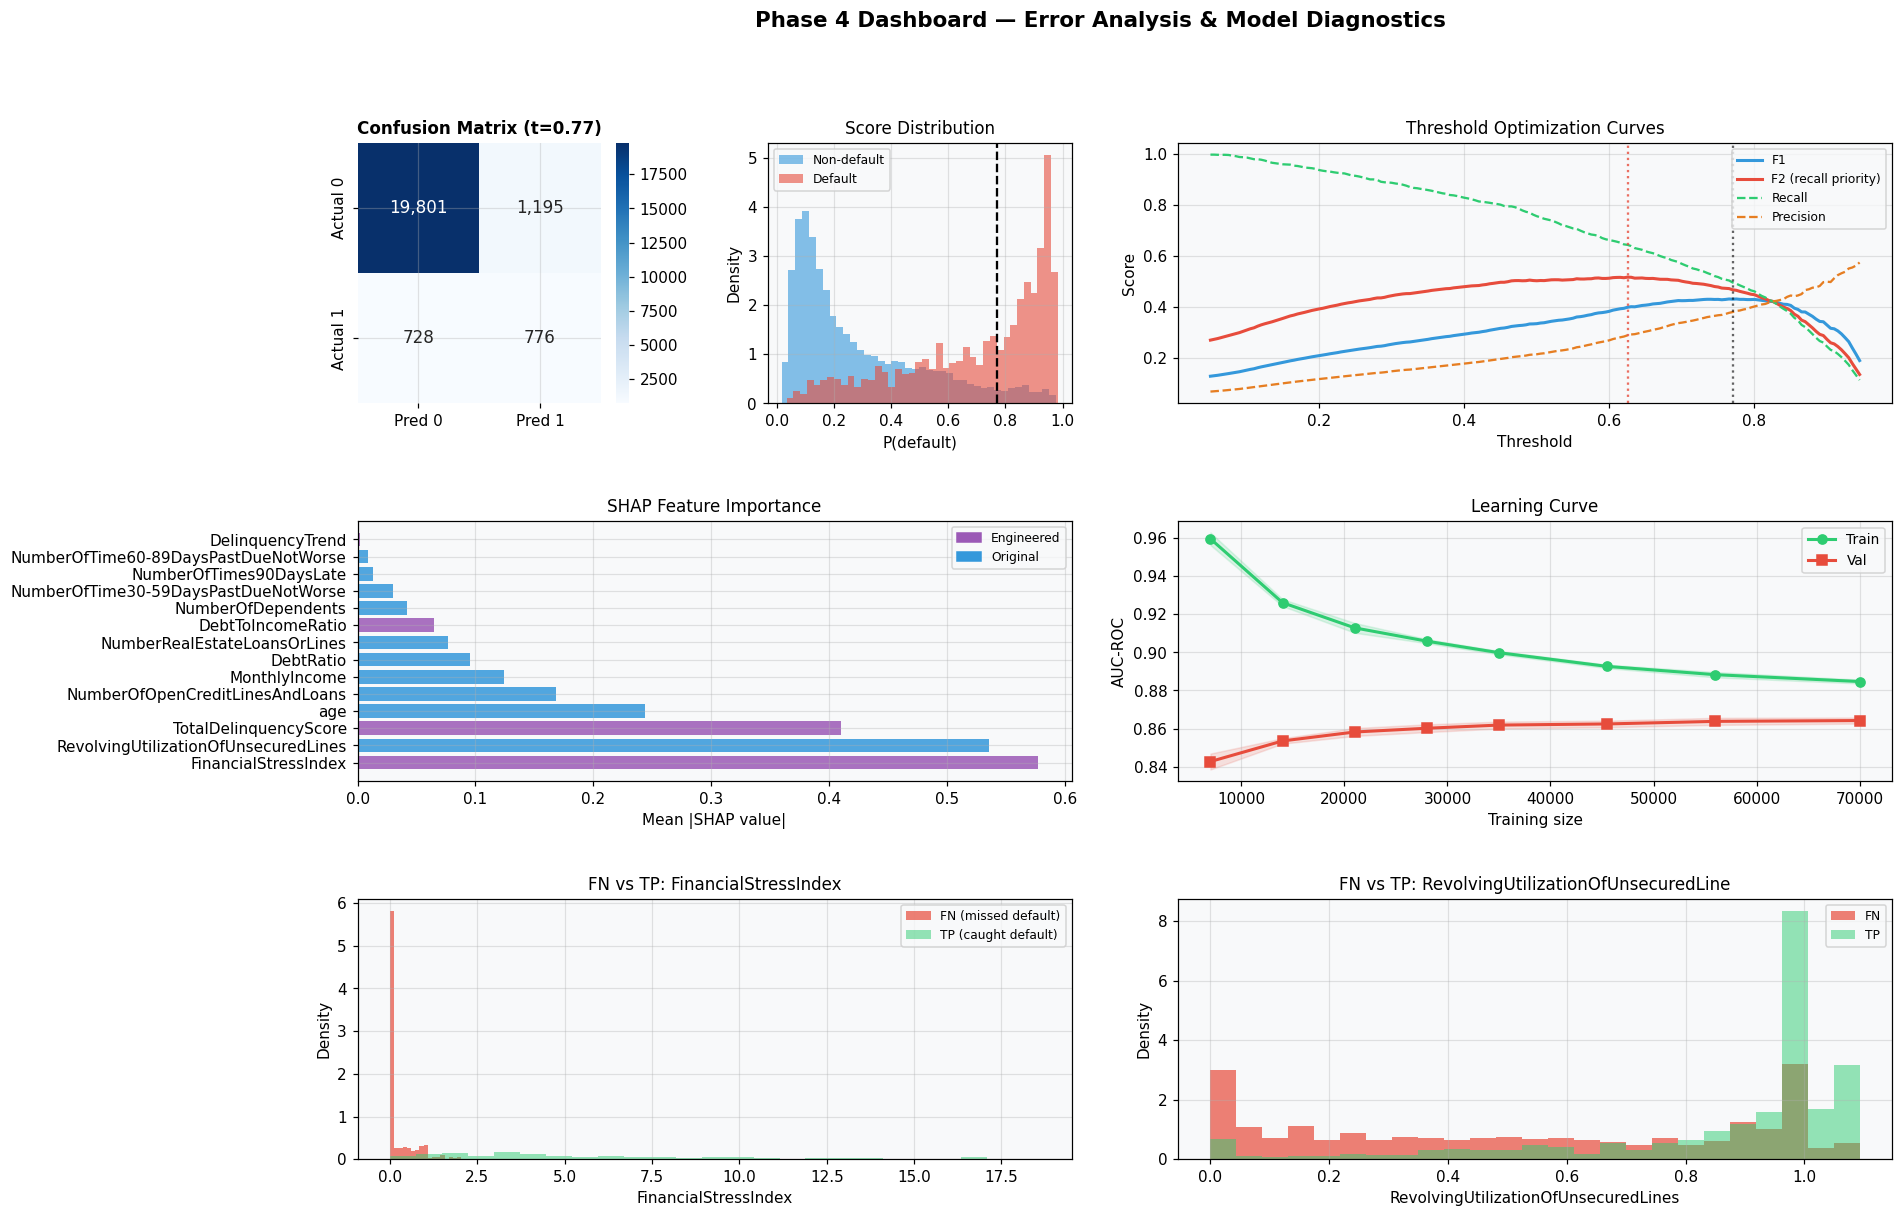

Saved: fig_30_analysis_dashboard.png
Phase 4 complete!


In [20]:
# ─── Final visualization: dashboard overview ─────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# 1. Confusion matrix (top left)
ax1 = fig.add_subplot(gs[0, 0])
cm_data = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_data, annot=True, fmt=',', cmap='Blues', ax=ax1,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            annot_kws={'size': 11})
ax1.set_title(f'Confusion Matrix (t={THRESHOLD})', fontweight='bold')

# 2. Score distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(proba_test[y_test == 0], bins=40, alpha=0.6, color=PALETTE['tn'], density=True, label='Non-default')
ax2.hist(proba_test[y_test == 1], bins=40, alpha=0.6, color=PALETTE['fn'], density=True, label='Default')
ax2.axvline(THRESHOLD, color='black', linestyle='--')
ax2.set_xlabel('P(default)'); ax2.set_ylabel('Density')
ax2.set_title('Score Distribution'); ax2.legend(fontsize=8)

# 3. F-beta curves (top right)
ax3 = fig.add_subplot(gs[0, 2:])
ax3.plot(thresholds, f1_scores, color='#3498db', lw=2, label='F1')
ax3.plot(thresholds, f2_scores, color='#e74c3c', lw=2, label='F2 (recall priority)')
ax3.plot(thresholds, rec_scores, color='#2ecc71', lw=1.5, linestyle='--', label='Recall')
ax3.plot(thresholds, prec_scores, color='#e67e22', lw=1.5, linestyle='--', label='Precision')
ax3.axvline(t_f2, color='#e74c3c', linestyle=':', alpha=0.8)
ax3.axvline(THRESHOLD, color='black', linestyle=':', alpha=0.6)
ax3.set_xlabel('Threshold'); ax3.set_ylabel('Score')
ax3.set_title('Threshold Optimization Curves'); ax3.legend(fontsize=8)

# 4. SHAP bar chart (middle)
ax4 = fig.add_subplot(gs[1, :2])
colors_shap = [PALETTE['engineered'] if f in ENGINEERED else PALETTE['original']
               for f in shap_importance.index]
ax4.barh(shap_importance.index, shap_importance.values, color=colors_shap, alpha=0.85)
ax4.set_xlabel('Mean |SHAP value|')
ax4.set_title('SHAP Feature Importance')
eng_p = mpatches.Patch(color=PALETTE['engineered'], label='Engineered')
ori_p = mpatches.Patch(color=PALETTE['original'], label='Original')
ax4.legend(handles=[eng_p, ori_p], fontsize=8)

# 5. Learning curve (middle right)
ax5 = fig.add_subplot(gs[1, 2:])
ax5.plot(train_sizes, train_mean, 'o-', color=PALETTE['tp'], lw=2, label='Train')
ax5.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=PALETTE['tp'])
ax5.plot(train_sizes, val_mean, 's-', color=PALETTE['default'], lw=2, label='Val')
ax5.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=PALETTE['default'])
ax5.set_xlabel('Training size'); ax5.set_ylabel('AUC-ROC')
ax5.set_title('Learning Curve'); ax5.legend(fontsize=9)

# 6. Error profile (bottom) — FN vs TP for top feature
ax6 = fig.add_subplot(gs[2, :2])
top_feat = shap_importance.index[0]
ax6.hist(df_fn[top_feat], bins=25, alpha=0.7, color=PALETTE['fn'], density=True, label='FN (missed default)')
ax6.hist(df_tp[top_feat], bins=25, alpha=0.5, color=PALETTE['tp'], density=True, label='TP (caught default)')
ax6.set_xlabel(top_feat); ax6.set_ylabel('Density')
ax6.set_title(f'FN vs TP: {top_feat[:35]}'); ax6.legend(fontsize=8)

ax7 = fig.add_subplot(gs[2, 2:])
top_feat2 = shap_importance.index[1]
ax7.hist(df_fn[top_feat2], bins=25, alpha=0.7, color=PALETTE['fn'], density=True, label='FN')
ax7.hist(df_tp[top_feat2], bins=25, alpha=0.5, color=PALETTE['tp'], density=True, label='TP')
ax7.set_xlabel(top_feat2); ax7.set_ylabel('Density')
ax7.set_title(f'FN vs TP: {top_feat2[:35]}'); ax7.legend(fontsize=8)

plt.suptitle('Phase 4 Dashboard — Error Analysis & Model Diagnostics',
             fontsize=14, fontweight='bold')
plt.savefig('../reports/fig_30_analysis_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: fig_30_analysis_dashboard.png")
print("Phase 4 complete!")
